# Vehicle Traffic Speed Violin Map Analysis

Violin plots combine box plots and kernel density estimations to show probability density profiles at different value levels. In traffic engineering, violin plots map vehicle velocity distributions to identify speeding anomalies and congestion peaks. This notebook generates synthetic speed readings across four highway sensors (8,000 observations total) and visualises them using a customized Seaborn Violin plot.



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate traffic speed telemetry (8,000 readings across 4 highway checkpoints)
np.random.seed(146)
n_readings = 8000

sensors = np.random.choice(['Sensor_1 (Urban)', 'Sensor_2 (Rural)', 'Sensor_3 (Bridge)', 'Sensor_4 (Tunnel)'], size=n_readings)
speeds = []

for s in sensors:
    if 'Urban' in s:
        # Lower speeds, higher congestion variance
        speed = np.random.normal(54, 8)
    elif 'Rural' in s:
        # Higher speeds, lower variance
        speed = np.random.normal(72, 5)
    elif 'Bridge' in s:
        speed = np.random.normal(63, 6)
    else: # Tunnel
        speed = np.random.normal(58, 4)
        
    speeds.append(speed)

df_traffic = pd.DataFrame({
    'Sensor_Location': sensors,
    'Velocity_mph': np.clip(speeds, 20.0, 100.0)
})

df_traffic.head(10)



,Sensor_Location,Velocity_mph
0,Sensor_4 (Tunnel),57.940976
1,Sensor_3 (Bridge),60.548759
2,Sensor_2 (Rural),69.843580
3,Sensor_3 (Bridge),62.971244
4,Sensor_1 (Urban),48.651397
5,Sensor_1 (Urban),62.273319
6,Sensor_2 (Rural),70.553143
7,Sensor_2 (Rural),81.394018
8,Sensor_2 (Rural),71.040541
9,Sensor_1 (Urban),41.293326


## Telemetry Aggregations

We evaluate mean speeds and calculate percentages exceeding the 65 mph limit.



In [2]:
df_stats = df_traffic.groupby('Sensor_Location').agg(
    Avg_Speed=('Velocity_mph', 'mean'),
    Std_Dev=('Velocity_mph', 'std'),
    Max_Speed=('Velocity_mph', 'max')
)

# Percentage exceeding speed limit (65mph)
df_stats['Speeding_Ratio_Pct'] = df_traffic.groupby('Sensor_Location').apply(
    lambda x: (x['Velocity_mph'] > 65.0).sum() / len(x) * 100,
    include_groups=False
)

print("Highway Sensor Speed Telemetry Summary:")
df_stats



Highway Sensor Speed Telemetry Summary:


,Avg_Speed,Std_Dev,Max_Speed,Speeding_Ratio_Pct
Sensor_Location,,,,
Sensor_1 (Urban),54.200843,7.980204,80.698397,8.796764
Sensor_2 (Rural),71.834618,5.027072,87.666001,91.709054
Sensor_3 (Bridge),63.073049,5.957432,82.073192,36.725664
Sensor_4 (Tunnel),58.080513,3.879530,72.370775,3.857567


## Annotated Seaborn Violin Plot

Using Seaborn violin plots, we outline velocity profiles, overlaying quartiles and highlighting the 65 mph speed limit.



<cell>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<cell>:20: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



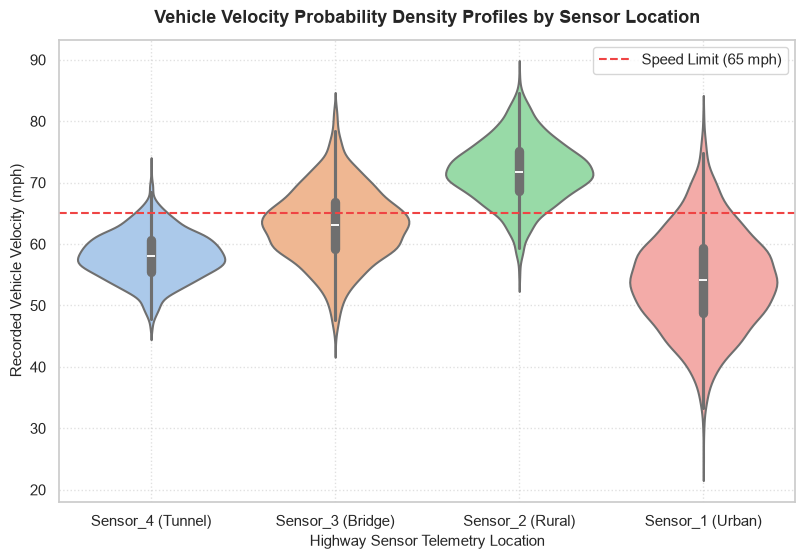

In [3]:
plt.figure(figsize=(9.5, 6))

sns.violinplot(
    x='Sensor_Location', 
    y='Velocity_mph', 
    data=df_traffic, 
    palette='pastel',
    inner='box', # Show inner boxplot components inside the violins
    linewidth=1.5
)

# Overlay speed limit baseline
plt.axhline(65.0, color='#EF4444', linestyle='--', linewidth=1.5, label='Speed Limit (65 mph)')

plt.title('Vehicle Velocity Probability Density Profiles by Sensor Location', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Highway Sensor Telemetry Location', fontsize=11)
plt.ylabel('Recorded Vehicle Velocity (mph)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()
